<a href="https://colab.research.google.com/github/Naganathsd20/Diabetes-Prediction-ML/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Diabetes Prediction Using Machine Learning with Support Vector Machine (SVM)

 Internship Project
 Developed by: Naganath S Dharwadkar

In [ ]:
#STEP 1 Import Libraries
#Import the required Python libraries for data analysis, visualization, machine learning, and model evaluation.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [ ]:
#STEP 2 Load Dataset
#Load the diabetes dataset into a Pandas DataFrame.
diabetes_dataset = pd.read_csv('/content/diabetes.csv')

In [ ]:
#STEP3 DisplayDataset
#Display the first five records of the dataset.
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
#STEP4 Dataset Shape
diabetes_dataset.shape

(768, 9)

In [ ]:
#STEP5 Statistical Summary of dataset
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
#STEP6 Informattion on Dataset which display column names,data types and non-null values
diabetes_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
#STEP 7 Missinge values of dataset
diabetes_dataset.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
#STEP 8 Diabetes count of diabetic and non diabetic patients
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


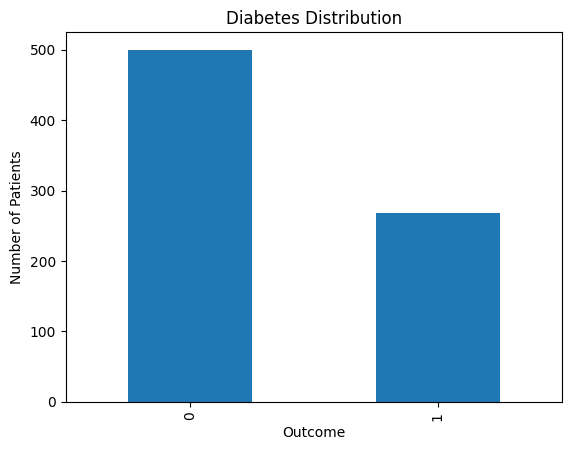

In [ ]:
#STEP 9 Diabetes Distribution Graph
diabetes_dataset['Outcome'].value_counts().plot(kind='bar')

plt.title("Diabetes Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

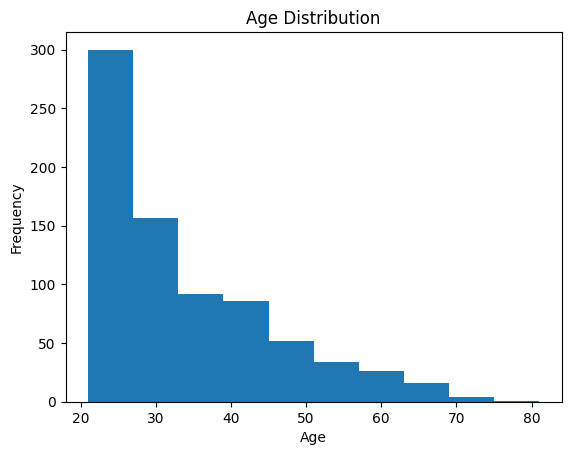

In [ ]:
#STEP 10 Age distributin of patients.
plt.hist(diabetes_dataset['Age'], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [ ]:
#STEP 11 Group mean which compares the average values of each feature for both classes
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [ ]:
#STEP 12 Feature and Target Separation
#Separate the input features and target variable
X = diabetes_dataset.drop(columns='Outcome', axis=1)
Y = diabetes_dataset['Outcome']

In [ ]:
#STEP 13 Data Standardization
#Scale the features to improve model performance.
scaler = StandardScaler()

scaler.fit(X)

standardized_data = scaler.transform(X)

X = standardized_data

In [ ]:
#STEP 14 Train-Test Split
#Split the dataset into training and testing sets.
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=2
)

In [ ]:
#STEP 15 Train SVM Model
#Train the Support Vector Machine classifier.
classifier = svm.SVC(kernel='linear')

classifier.fit(X_train, Y_train)

SVC(kernel='linear')

In [ ]:
#STEP 16 Training Accuracy
#Evaluate the model using the training dataset.
X_train_prediction = classifier.predict(X_train)

training_accuracy = accuracy_score(
    X_train_prediction,
    Y_train
)

print("Training Accuracy :", training_accuracy * 100, "%")

Training Accuracy : 78.66449511400651 %


In [ ]:
#STEP 17  Testing Accuracy
#Evaluate the model using the testing dataset.
X_test_prediction = classifier.predict(X_test)

testing_accuracy = accuracy_score(
    X_test_prediction,
    Y_test
)

print("Testing Accuracy :", testing_accuracy * 100, "%")

Testing Accuracy : 77.27272727272727 %


In [ ]:
#STEP 18 Diabetes Prediction
#Predict whether a patient is diabetic based on input data.
# Convert to NumPy array
input_data_as_numpy_array = np.asarray(input_data)

# Reshape the array
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Standardize
std_data = scaler.transform(input_data_reshaped)

# Predict
prediction = classifier.predict(std_data)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
#STEP 19 Prediction Result
#Display the final prediction generated by the model.
if prediction[0] == 0:
    print("Prediction Result : Non-Diabetic")
    print("The model predicts that the person is unlikely to have diabetes.")
else:
    print("Prediction Result : Diabetic")
    print("The model predicts that the person is likely to have diabetes.")

Prediction Result : Diabetic
The model predicts that the person is likely to have diabetes.


**CONCLUSION :**

In this project, I developed a Diabetes Prediction System using Machine Learning with the Support Vector Machine (SVM) algorithm. I explored and analyzed the diabetes dataset, checked for missing values, standardized the data, and trained the model to predict whether a person is diabetic based on medical features. The trained model achieved good accuracy on both the training and testing datasets and successfully predicted the outcome for new patient data. This project helped me understand the complete machine learning workflow, including data preprocessing, model training, model evaluation, and prediction. It also demonstrated how machine learning can support healthcare by assisting in the early prediction of diabetes.

**TESTING THE MODEL WITH CUSTOM INPUT**

In [ ]:
input_data = (
    2,      # Pregnancies
    120,    # Glucose
    70,     # Blood Pressure
    20,     # Skin Thickness
    85,     # Insulin
    25.5,   # BMI
    0.35,   # Diabetes Pedigree Function
    30      # Age
)

In [ ]:
input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

std_data = scaler.transform(input_data_reshaped)

prediction = classifier.predict(std_data)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Display Result
if prediction[0] == 0:
    print("Prediction Result: Non-Diabetic")
    print("The model predicts that the person is unlikely to have diabetes.")
else:
    print("Prediction Result: Diabetic")
    print("The model predicts that the person is likely to have diabetes.")

Prediction Result: Non-Diabetic
The model predicts that the person is unlikely to have diabetes.
